In [5]:
import pandas as pd
from scipy.interpolate import splrep, BSpline
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
from scipy.stats import bootstrap
import scipy.stats
import scipy

from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import os


In [6]:
Heisenberg_ground_states = {"5": -8.472135954999581,
                            "6": -11.21110255092798,
                            "7": -12.420717027386775,
                            "8": -14.604373635748704,
                            "9": -16.189199135748044,
                            }

In [7]:


def mean_confidence_interval(data, confidence):
    res = bootstrap(
        data=(data,),
        statistic=np.mean,            
        method="BCa",                 
        confidence_level = confidence,
        n_resamples=10000
    )

    ci_low, ci_high = res.confidence_interval.low, res.confidence_interval.high

    mean = data.mean()

    return mean, ci_low, ci_high


def compute_mean_and_confidence(df, runs, confidence):
    means = []
    lower_bounds = []
    upper_bounds = []

    for i, row in df.iterrows():
        mean, lower_bound, upper_bound = mean_confidence_interval(data = row[:runs], confidence = confidence)
        
        means.append(mean)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    return np.array(means), np.array(lower_bounds), np.array(upper_bounds)



## Rotosolve results

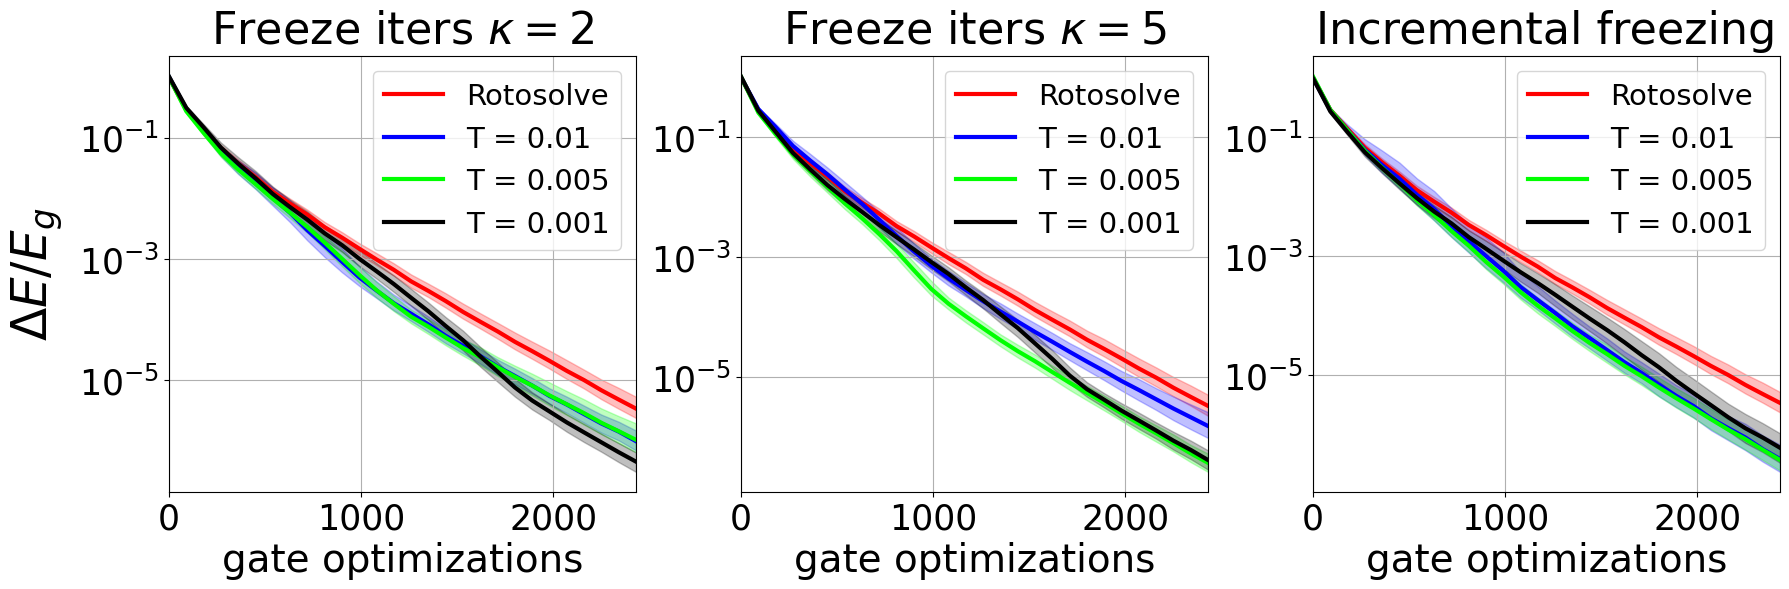

In [9]:
data_folder_rotosolve = f"../../data_folders/1DHeisenberg_5Q_Rotosolve_data"


qubit = 5
iters = 10
layers = 5*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.01, 0.005, 0.001]

freeze_iters = [2, 5,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(18)

if len(freeze_iters) == 1:
    axes = [axes]


# select every k-th row for faster plotting
every_n_row = 90

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="Rotosolve")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d{d}_FreezeIters{fiter}_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)


        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)

    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=32, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=32, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=28)
    
    ax.tick_params(labelsize=25)

    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")

    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()



Rotosolve, Median=1.7347212126773955e-06
T=0.01, Median=5.65144534501651e-07
T=0.005, Median=3.7316240637736465e-07
T=0.001, Median=1.5619487237359266e-07

Rotosolve, Median=1.7347212126773955e-06
T=0.01, Median=5.282147631112949e-07
T=0.005, Median=1.467757109629638e-07
T=0.001, Median=1.957680569375599e-07

Rotosolve, Median=1.7347212126773955e-06
T=0.01, Median=1.022231772026328e-07
T=0.005, Median=1.4452301988797896e-07
T=0.001, Median=1.1434453133430863e-07


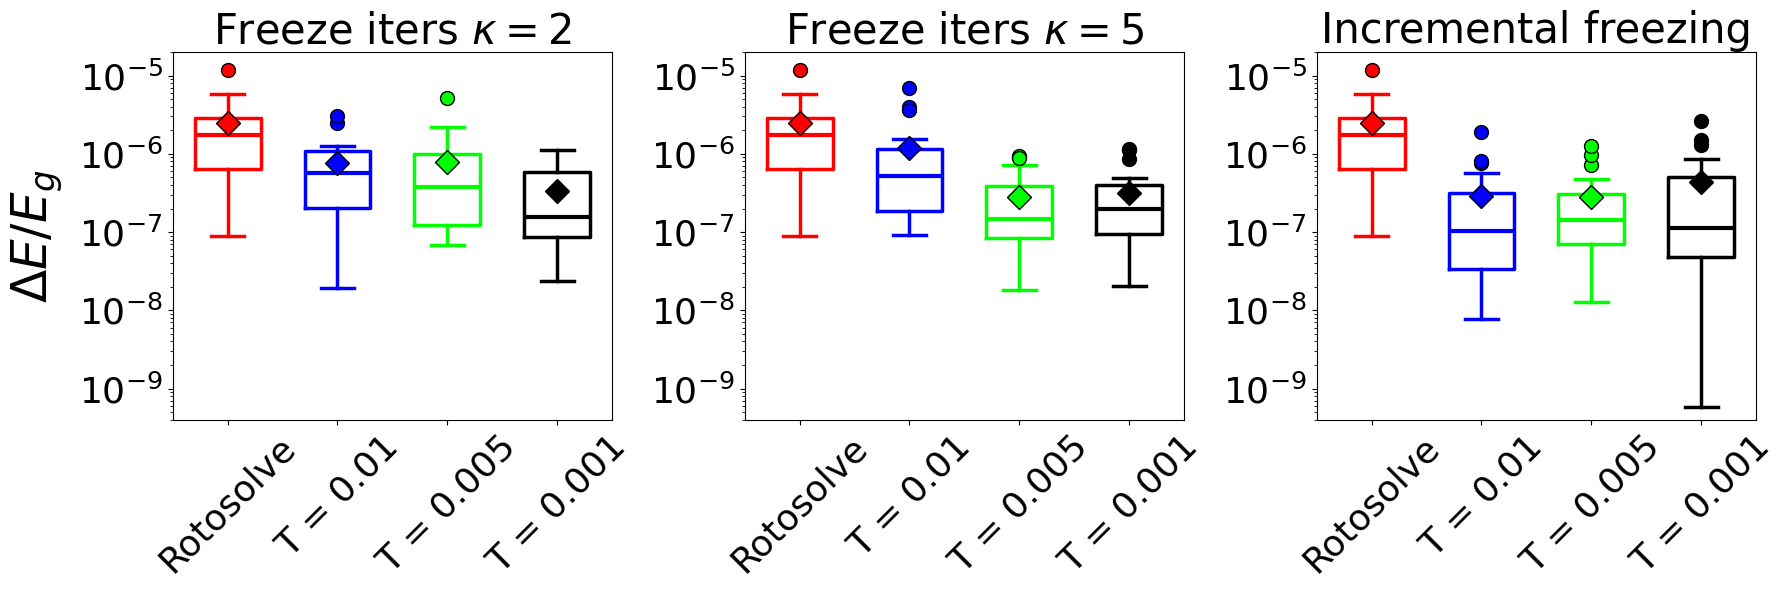

In [14]:
data_folder_rotosolve = f"../../data_folders/1DHeisenberg_5Q_Rotosolve_data"

qubit = 5
iters = 10
layers = 5*qubit
trials = 20

freeze_iters = [2,5, "inc"]


vals = [0.01, 0.005 ,0.001]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(18)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["Rotosolve", "T = 0.01", "T = 0.005", "T = 0.001"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])

    len_roto = len(df1)

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        df3 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        df4 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d0.001_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d0.01_FreezeIters{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        df3 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d0.005_FreezeIters{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        df4 = pd.read_excel(f"{data_folder_rotosolve}/1DHeisenberg_{qubit}Q_rotosolve_GateFreeze_d0.001_FreezeIters{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    
    df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df3 = np.abs((df3 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df4 = np.abs((df4 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    
    df2 = df2[:len_roto]
    df3 = df3[:len_roto]
    df4 = df4[:len_roto]

    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nRotosolve, Median={np.median(row1)}")
    print(f"T=0.01, Median={np.median(row2)}")
    print(f"T=0.005, Median={np.median(row3)}")
    print(f"T=0.001, Median={np.median(row4)}")

    data = [row1, row2, row3, row4]

    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)

        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    
    ax.set_ylim(4e-10, 2e-5)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()

# Fraxis results

### Fraxis - Parameter distance metric

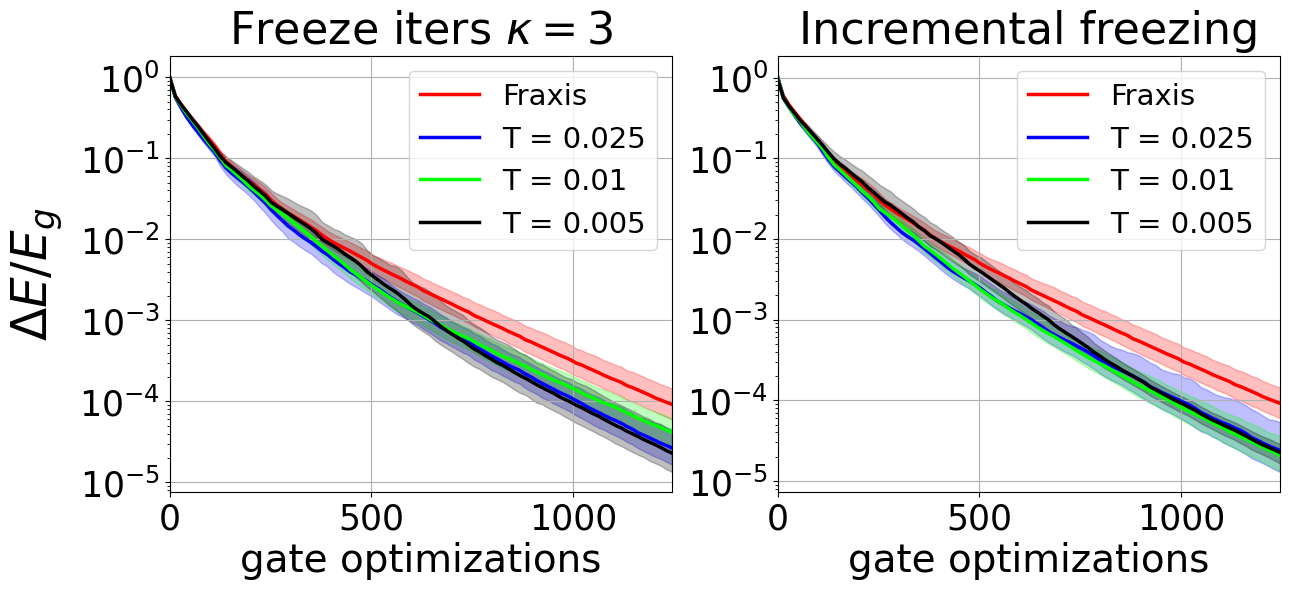

In [16]:
data_folder_fraxis = f"../../data_folders/1DHeisenberg_5Q_Fraxis_data"

qubit = 5
iters = 10
layers = 5*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.025, 0.01, 0.005]

freeze_iters = [3,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(13)

if len(freeze_iters) == 1:
    axes = [axes]

every_n_row = 14

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=2.5, color="red", label="Fraxis")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d{d}_FreezeIter{fiter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)


        ax.plot(xx, mean2, lw=2.5, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)

    

    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=32, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=32, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=28)
    ax.tick_params(labelsize=25)
    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")
    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()


Fraxis, Median=4.2160518580221695e-05
T=0.025, Median=1.1519469917027627e-05
T=0.01, Median=2.1394994180709178e-05
T=0.005, Median=6.2024031062211545e-06

Fraxis, Median=4.2160518580221695e-05
T=0.025, Median=9.510560083274215e-06
T=0.01, Median=1.066453136971969e-05
T=0.005, Median=1.840166449713716e-05


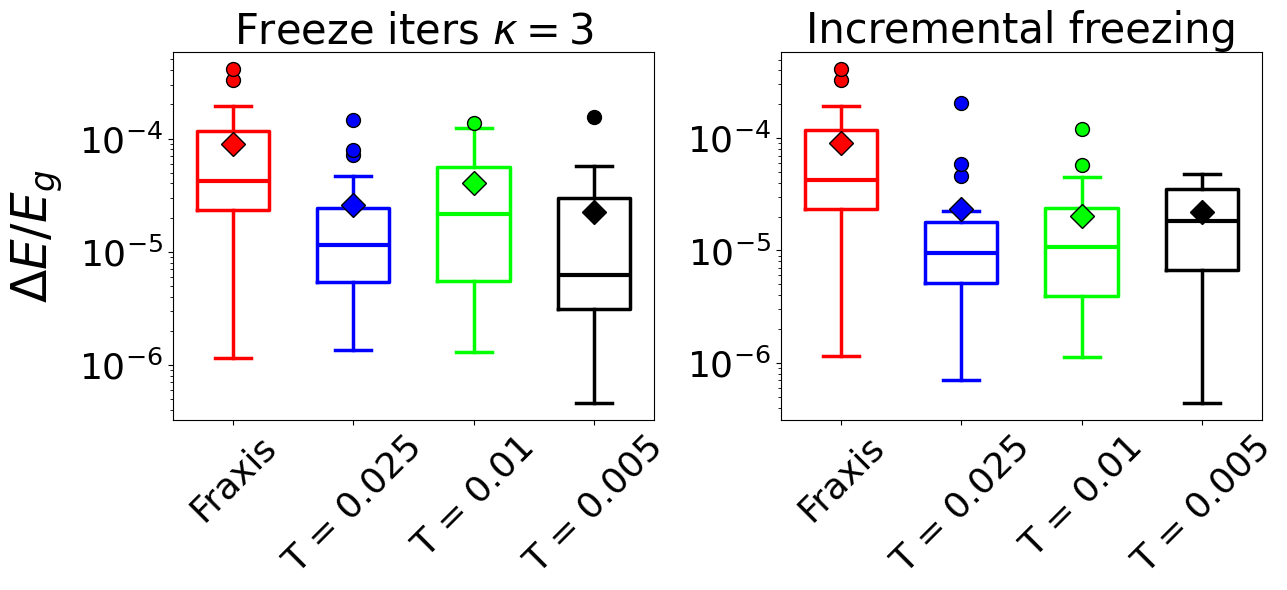

In [20]:
data_folder_fraxis = f"../../data_folders/1DHeisenberg_5Q_Fraxis_data"


qubit = 5
iters = 10
layers = 5*qubit
trials = 20

freeze_iters = [3, "inc"]


vals = [0.01, 0.005 ,0.001]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(13)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["Fraxis", "T = 0.025", "T = 0.01", "T = 0.005"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d0.025_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d0.025_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d0.01_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_GCdist_d0.005_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    
    df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df3 = np.abs((df3 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df4 = np.abs((df4 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    
    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nFraxis, Median={np.median(row1)}")
    print(f"T=0.025, Median={np.median(row2)}")
    print(f"T=0.01, Median={np.median(row3)}")
    print(f"T=0.005, Median={np.median(row4)}")

    data = [row1, row2, row3, row4]

    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)

        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()

### Fraxis - Matrix norm metric

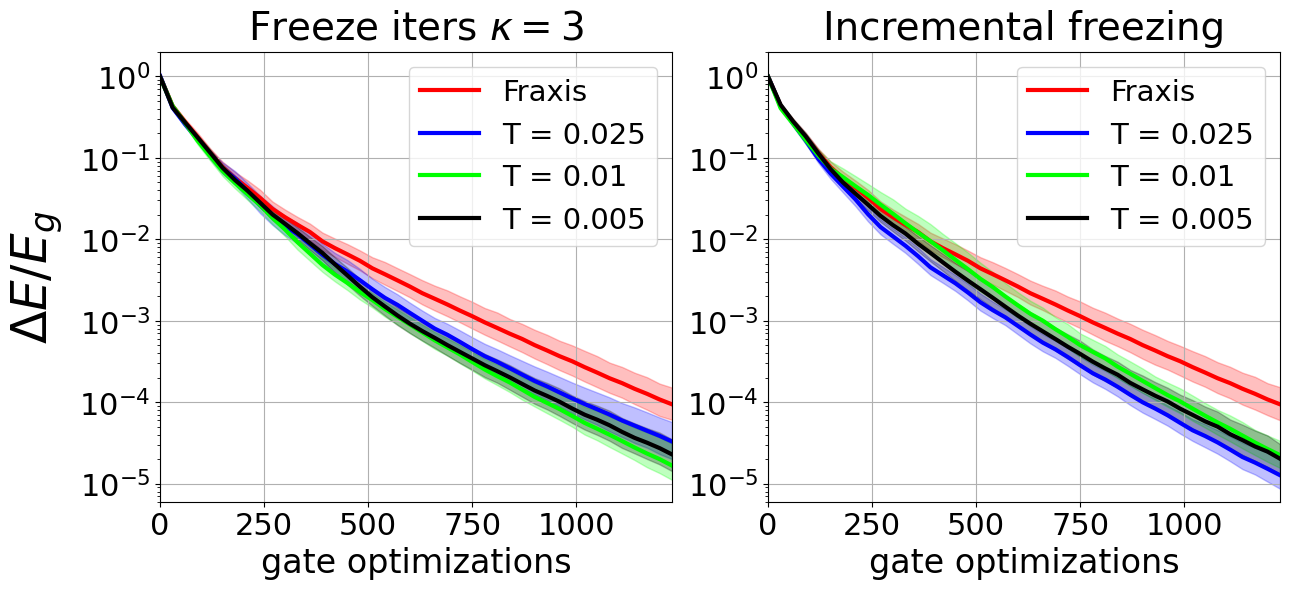

In [22]:
data_folder_fraxis = f"../../data_folders/1DHeisenberg_5Q_Fraxis_matrix_norm_data"

qubit = 5
iters = 10
layers = 5*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.025, 0.01, 0.005]

freeze_iters = [3,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(13)

if len(freeze_iters) == 1:
    axes = [axes]

every_n_row = 30

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="Fraxis")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_d{d}_FreezeIter{fiter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)

    
    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=28, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=28, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=24)
    
    ax.tick_params(labelsize=22)

    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")
    ax.set_ylim(6e-6, 2e0)
    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()


Fraxis, Median=3.919861327059277e-05
T=0.025, Median=1.1349774123531099e-05
T=0.01, Median=1.0467270648693552e-05
T=0.005, Median=8.840789751422526e-06

Fraxis, Median=3.919861327059277e-05
T=0.025, Median=7.79181072597015e-06
T=0.01, Median=1.3858845275526946e-05
T=0.005, Median=7.889518130802018e-06


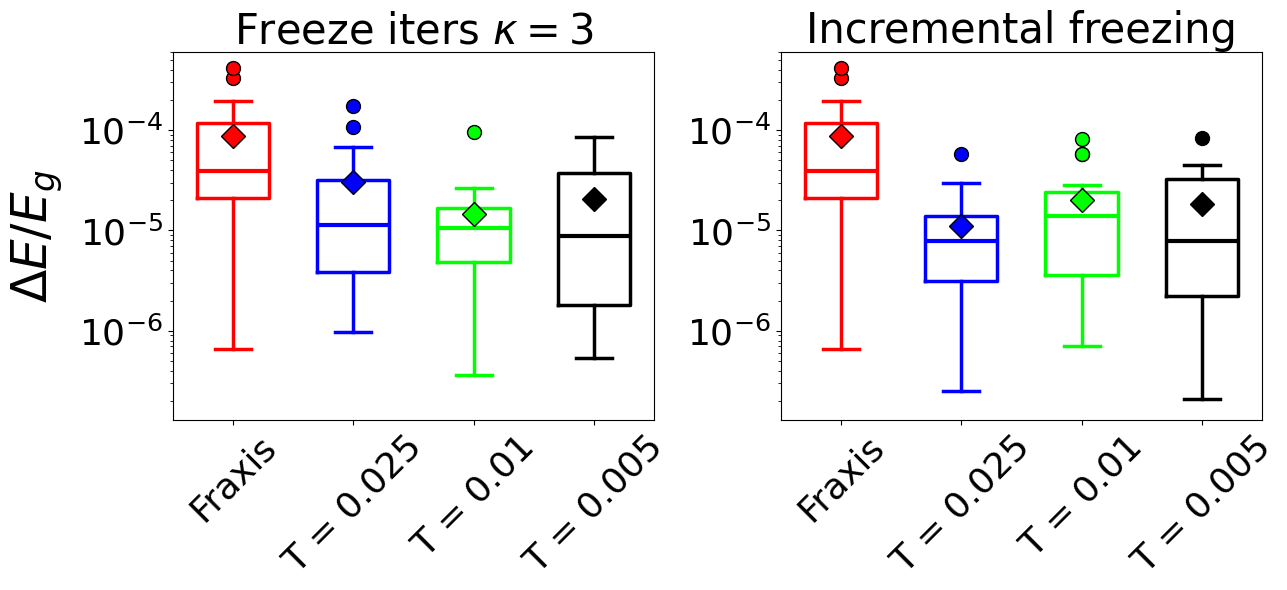

In [24]:
data_folder_fraxis = f"../../data_folders/1DHeisenberg_5Q_Fraxis_matrix_norm_data"

qubit = 5
iters = 10
layers = 5*qubit
trials = 20

freeze_iters = [3, "inc"]


vals = [0.01, 0.005 ,0.001]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(13)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["Fraxis", "T = 0.025", "T = 0.01", "T = 0.005"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_fraxis}/1DHeisenberg_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_d0.025_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_d0.025_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_d0.01_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_1DHeisenberg_{qubit}Q_Fraxis_GateFreeze_d0.005_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    
    df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df3 = np.abs((df3 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df4 = np.abs((df4 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    
    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nFraxis, Median={np.median(row1)}")
    print(f"T=0.025, Median={np.median(row2)}")
    print(f"T=0.01, Median={np.median(row3)}")
    print(f"T=0.005, Median={np.median(row4)}")
    
    data = [row1, row2, row3, row4]

    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)

        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    
    ax.set_ylim(1.3e-7, 6e-4)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)

fig.tight_layout()


# FQS Results

### FQS - parameter distance metric

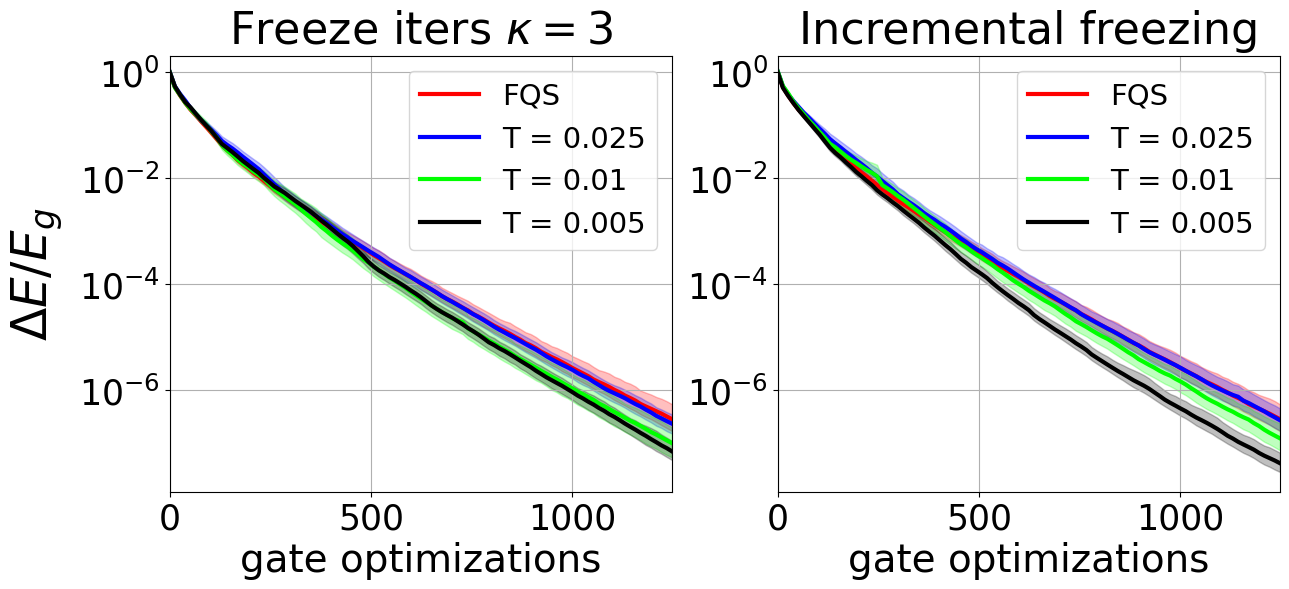

In [25]:
data_folder_fqs = f"../../data_folders/1DHeisenberg_5Q_FQS_data"

qubit = 5
iters = 10
layers = 5*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.025, 0.01, 0.005]

freeze_iters = [3,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(13)

if len(freeze_iters) == 1:
    axes = [axes]

every_n_row = 13

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="FQS")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d{d}_FreezeIter{fiter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)


    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=32, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=32, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=28)
    ax.tick_params(labelsize=25)
    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")
    ax.set_ylim(1.2e-8, 2e0)
    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()


FQS, Median=9.625061410494104e-08
T=0.01, Median=1.0926576205591561e-07
T=0.005, Median=1.862789364541664e-08
T=0.001, Median=4.682790321411949e-08

FQS, Median=9.625061410494104e-08
T=0.01, Median=7.255199057646864e-08
T=0.005, Median=5.169760082821495e-08
T=0.001, Median=2.2520782920306648e-08


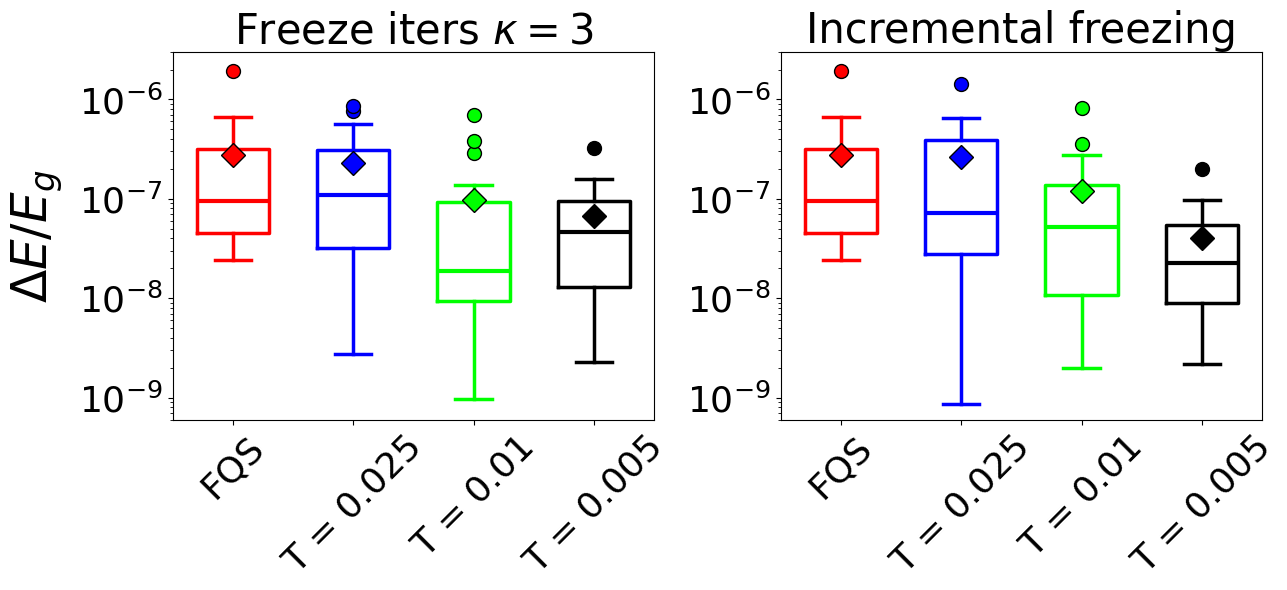

In [27]:
data_folder_fqs = f"../../data_folders/1DHeisenberg_5Q_FQS_data"

qubit = 5
iters = 10
layers = 5*qubit
trials = 20

freeze_iters = [3, "inc"]


vals = [0.01, 0.005 ,0.001]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(13)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["FQS", "T = 0.025", "T = 0.01", "T = 0.005"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d0.025_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d0.025_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d0.01_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_GateFreeze_GCdist_d0.005_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    
    df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df3 = np.abs((df3 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df4 = np.abs((df4 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    
    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    data = [row1, row2, row3, row4]

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nFQS, Median={np.median(row1)}")
    print(f"T=0.01, Median={np.median(row2)}")
    print(f"T=0.005, Median={np.median(row3)}")
    print(f"T=0.001, Median={np.median(row4)}")


    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)

        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    
    ax.set_ylim(6e-10, 3e-6)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)

fig.tight_layout()

### FQS - Matrix norm metric

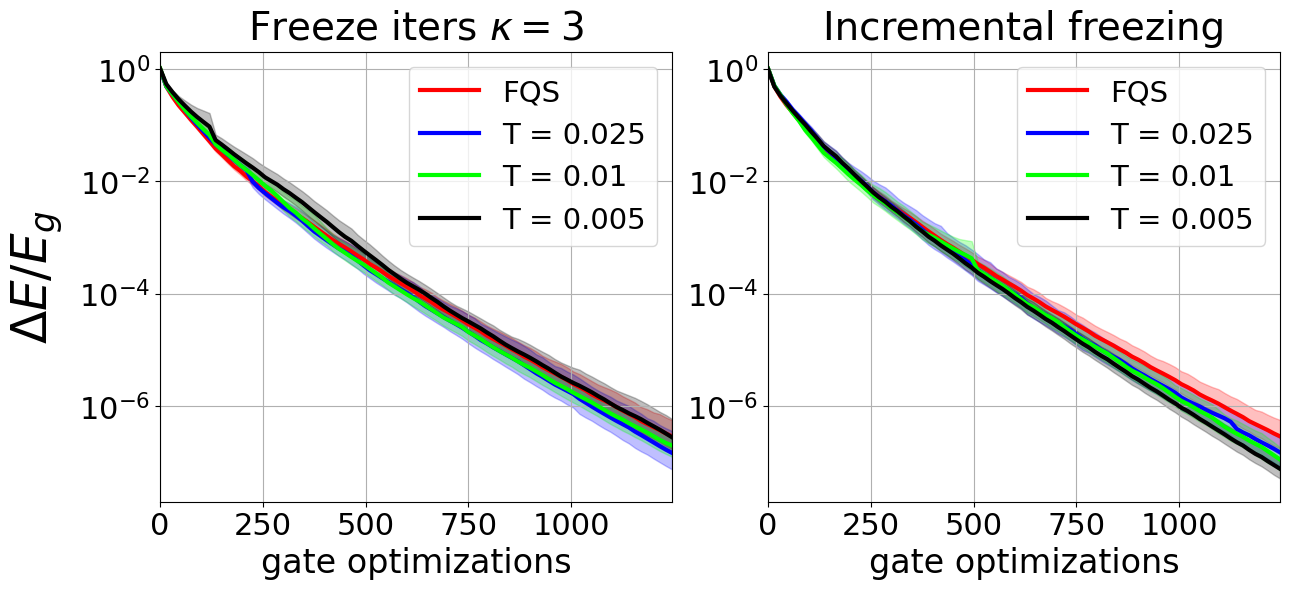

In [28]:
data_folder_fqs = f"../../data_folders/1DHeisenberg_5Q_FQS_matrix_norm_data"

qubit = 5
iters = 10
layers = 5*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.025, 0.01, 0.005]

freeze_iters = [3,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(13)

if len(freeze_iters) == 1:
    axes = [axes]

every_n_row = 15

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="FQS")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_1DHeisenberg_{qubit}Q_FQS_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_1DHeisenberg_{qubit}Q_FQS_GateFreeze_d{d}_FreezeIter{fiter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
        df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)

    
    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=28, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=28, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=24)
    
    ax.tick_params(labelsize=22)

    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")
    ax.set_ylim(2e-8, 2e0)

    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()




FQS, Median=9.625061410494104e-08
T=0.01, Median=5.370338289383394e-08
T=0.005, Median=5.1697332240325974e-08
T=0.001, Median=7.597824791714879e-08

FQS, Median=9.625061410494104e-08
T=0.01, Median=4.264151688234381e-08
T=0.005, Median=6.878150105889585e-08
T=0.001, Median=5.774032061310178e-08


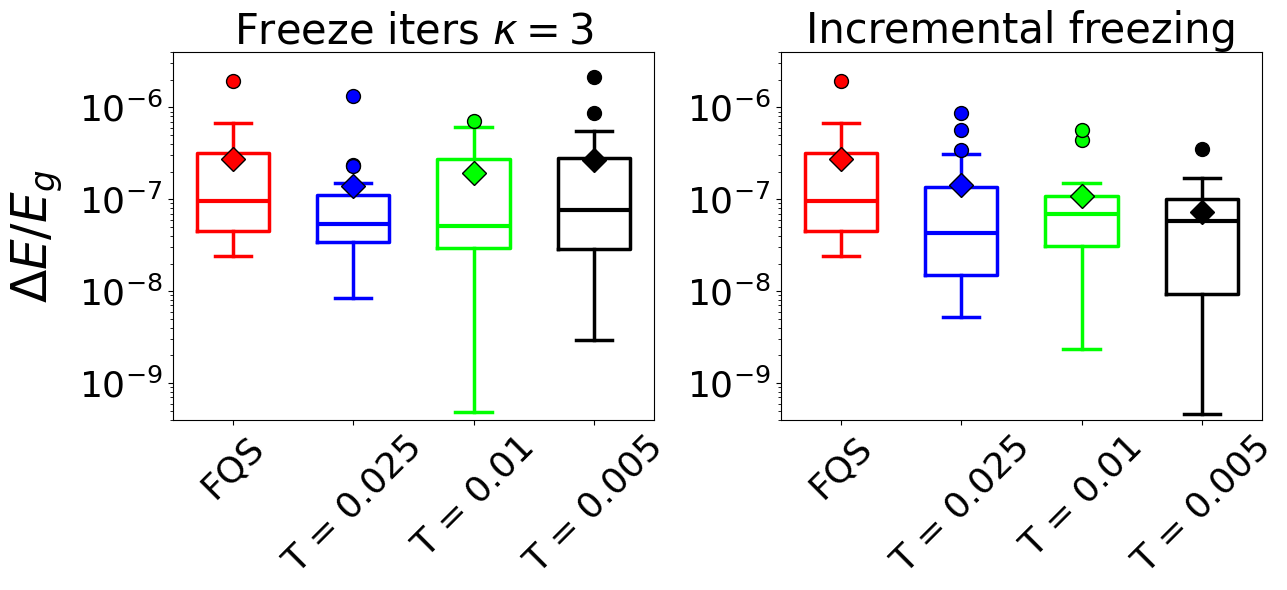

In [29]:
data_folder_fqs = f"../../data_folders/1DHeisenberg_5Q_FQS_matrix_norm_data"

qubit = 5
iters = 10
layers = 5*qubit
trials = 20

freeze_iters = [3, "inc"]


vals = [0.025, 0.01 ,0.005]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(13)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["FQS", "T = 0.025", "T = 0.01", "T = 0.005"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_fqs}/1DHeisenberg_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_1DHeisenberg_{qubit}Q_FQS_GateFreeze_d0.025_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_1DHeisenberg_{qubit}Q_FQS_GateFreeze_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_1DHeisenberg_{qubit}Q_FQS_GateFreeze_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_1DHeisenberg_{qubit}Q_FQS_GateFreeze_d0.025_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_1DHeisenberg_{qubit}Q_FQS_GateFreeze_d0.01_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_1DHeisenberg_{qubit}Q_FQS_GateFreeze_d0.005_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    
    df2 = np.abs((df2 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df3 = np.abs((df3 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    df4 = np.abs((df4 - Heisenberg_ground_states[f"{qubit}"]) / Heisenberg_ground_states[f"{qubit}"])
    
    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    data = [row1, row2, row3, row4]

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nFQS, Median={np.median(row1)}")
    print(f"T=0.01, Median={np.median(row2)}")
    print(f"T=0.005, Median={np.median(row3)}")
    print(f"T=0.001, Median={np.median(row4)}")
    
    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)
        # Use positions to space boxplots; boxprops sets the color
        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    
    ax.set_ylim(4e-10, 4e-6)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()